In [73]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import os
import torch
import seaborn as sns
import copy

In [74]:
import sys
sys.path.append('../code/BalancingControl')
import tmaze_utils as tu
import inference_utils as iu
import inference as inf

import misc

In [75]:
groups = ["control", "cie"]

agents = ["BCC_2pars_planning_repetition_weight"]

In [76]:
results_dir = os.path.abspath('results')
inference_folder = os.path.join(results_dir, "inference")
print(inference_folder)

/home/sarah/src/TMaze/cie_task/results/inference


In [77]:
results = {}
data = {}
n_agents = {}
num_steps = 600

for grp in groups:
    base_dir = "processed_data"
    fname_data = os.path.join(base_dir, f"TMaze_{grp}_structured_data.json")
    structured_data = misc.load_file(fname_data, fname_data)
    data[grp] = structured_data
    n_agents[grp] = len(structured_data["subject"][0])
    for agt in agents:
        fname_base = agt+"_"+grp+"_inference_"
        fname_str = fname_base + str(num_steps)+'_'+str(n_agents[grp])+'agents'
        # define folder where we want to save data
        base_dir = os.path.join(inference_folder,fname_base[:-1])
        mean_df, sample_df, locs_df = iu.load_samples(base_dir, fname_str) 
        print(f"{agt}_{grp}")
        results[f"{agt}_{grp}"] = {}
        results[f"{agt}_{grp}"]["mean_df"] = mean_df
        results[f"{agt}_{grp}"]["sample_df"] = sample_df
        results[f"{agt}_{grp}"]["locs_df"] = locs_df

BCC_2pars_planning_repetition_weight_control
BCC_2pars_planning_repetition_weight_cie


In [78]:
base_dir = "processed_data"
fname_plot_df = os.path.join(base_dir, "plot_df.csv")
plot_df = pd.read_csv(fname_plot_df)

In [79]:
plot_df["correct"][plot_df["trial_type"]=="early test"]

75      0.0
76      0.0
77      0.0
78      1.0
79      0.0
       ... 
2315    0.0
2316    0.0
2317    0.0
2318    1.0
2319    0.0
Name: correct, Length: 75, dtype: float64

In [80]:
plot_df[plot_df["trial_type"]=="early test"].groupby(["animal", "group"])["correct"].mean()

animal  group  
20.0    control    0.4
24.0    cie        0.2
25.0    cie        0.2
26.0    cie        0.2
27.0    cie        0.4
32.0    cie        0.4
33.0    cie        0.0
34.0    cie        0.2
35.0    cie        0.2
38.0    control    0.6
39.0    control    0.4
44.0    control    0.2
45.0    control    0.2
46.0    control    1.0
47.0    control    0.6
Name: correct, dtype: float64

In [81]:
plot_df[plot_df["trial_type"]=="late test"].groupby(["animal", "group"])["correct"].mean()

animal  group  
20.0    control    0.4
24.0    cie        0.4
25.0    cie        0.4
26.0    cie        0.2
27.0    cie        0.8
32.0    cie        0.6
33.0    cie        0.2
34.0    cie        0.8
35.0    cie        0.6
38.0    control    0.8
39.0    control    0.4
44.0    control    0.6
45.0    control    1.0
46.0    control    0.2
47.0    control    0.8
Name: correct, dtype: float64

In [82]:
print(results.keys())
results[agents[0]+"_cie"]

dict_keys(['BCC_2pars_planning_repetition_weight_control', 'BCC_2pars_planning_repetition_weight_cie'])


{'mean_df':    Unnamed: 0  inferred dec temp  subject  inferred habitual tendency
 0           0           0.696283        0                    1.708958
 1           1           1.758763        1                    4.133859
 2           2           0.847165        2                    2.125088
 3           3           3.131046        3                    1.830917
 4           4           0.878095        4                    2.339238
 5           5           0.961701        5                    5.219173
 6           6           1.540068        6                    2.225346
 7           7           1.807071        7                    3.004142,
 'sample_df':       Unnamed: 0  dec temp  habitual tendency  subject
 0              0  0.765579           1.211647        0
 1              1  1.182951           3.086999        1
 2              2  0.797661           2.234625        2
 3              3  2.975147           1.787781        3
 4              4  0.779013           1.637667        4


In [83]:
cie_early_test_accuracy = plot_df[plot_df["trial_type"]=="early test"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
cie_late_test_accuracy = plot_df[plot_df["trial_type"]=="late test"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
cie_early_training_accuracy = plot_df[plot_df["detailed_trial_type"]=="early training"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
cie_late_training_accuracy = plot_df[plot_df["detailed_trial_type"]=="late training"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
cie_early_test_first_choice = plot_df[plot_df["trial"]==75][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
cie_late_test_first_choice = plot_df[plot_df["trial"]==155][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values

cie_dec_temp = results[agents[0]+"_cie"]["mean_df"]["inferred dec temp"]
cie_hab_tend = results[agents[0]+"_cie"]["mean_df"]["inferred habitual tendency"]

/tmp/ipykernel_17545/1125224830.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cie_early_test_accuracy = plot_df[plot_df["trial_type"]=="early test"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
/tmp/ipykernel_17545/1125224830.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cie_late_test_accuracy = plot_df[plot_df["trial_type"]=="late test"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
/tmp/ipykernel_17545/1125224830.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cie_early_training_accuracy = plot_df[plot_df["detailed_trial_type"]=="early training"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
/tmp/ipykernel_17545/1125224830.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cie_late_training_accuracy = plot_df[plot_df["detailed_trial_type"]=="late training"][plot_df["gro

In [84]:
cie_dict = {"early training acc": cie_early_training_accuracy, "early test acc": cie_early_test_accuracy, 
                "late training acc": cie_late_training_accuracy, "late test acc": cie_late_test_accuracy,
                "early training first": cie_early_test_first_choice, "late training first": cie_late_test_first_choice,
                "dec temp": cie_dec_temp, "hab tend": cie_hab_tend}

cie_df = pd.DataFrame(cie_dict)

In [85]:
cie_df.corr()

,early training acc,early test acc,late training acc,late test acc,early training first,late training first,dec temp,hab tend
early training acc,1.000000,-0.461849,-0.635086,-0.502670,-0.437329,-0.330590,-0.493526,-0.185068
early test acc,-0.461849,1.000000,0.694716,0.652753,0.551677,-0.208514,0.440789,-0.695051
late training acc,-0.635086,0.694716,1.000000,0.348723,0.830589,0.354441,0.126361,-0.221361
late test acc,-0.502670,0.652753,0.348723,1.000000,0.169031,0.223607,0.653275,-0.498693
early training first,-0.437329,0.551677,0.830589,0.169031,1.000000,0.377964,-0.287769,-0.157505
late training first,-0.330590,-0.208514,0.354441,0.223607,0.377964,1.000000,-0.206489,0.321627
dec temp,-0.493526,0.440789,0.126361,0.653275,-0.287769,-0.206489,1.000000,-0.126235
hab tend,-0.185068,-0.695051,-0.221361,-0.498693,-0.157505,0.321627,-0.126235,1.000000


In [86]:
control_early_test_accuracy = plot_df[plot_df["detailed_trial_type"]=="early test"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
control_late_test_accuracy = plot_df[plot_df["detailed_trial_type"]=="late test"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
control_early_training_accuracy = plot_df[plot_df["detailed_trial_type"]=="early training"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
control_late_training_accuracy = plot_df[plot_df["detailed_trial_type"]=="late training"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
control_early_test_first_choice = plot_df[plot_df["trial"]==75][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
control_late_test_first_choice = plot_df[plot_df["trial"]==155][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values

control_dec_temp = results[agents[0]+"_control"]["mean_df"]["inferred dec temp"]
control_hab_tend = results[agents[0]+"_control"]["mean_df"]["inferred habitual tendency"]

/tmp/ipykernel_17545/1103311736.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  control_early_test_accuracy = plot_df[plot_df["detailed_trial_type"]=="early test"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
/tmp/ipykernel_17545/1103311736.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  control_late_test_accuracy = plot_df[plot_df["detailed_trial_type"]=="late test"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
/tmp/ipykernel_17545/1103311736.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  control_early_training_accuracy = plot_df[plot_df["detailed_trial_type"]=="early training"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
/tmp/ipykernel_17545/1103311736.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  control_late_training_accuracy = plot_df[plot_df["detail

In [87]:
control_dict = {"early training acc": control_early_training_accuracy, "early test acc": control_early_test_accuracy, 
                "late training acc": control_late_training_accuracy, "late test acc": control_late_test_accuracy,
                "early training first": control_early_test_first_choice, "late training first": control_late_test_first_choice,
                "dec temp": control_dec_temp, "hab tend": control_hab_tend}

control_df = pd.DataFrame(control_dict)

In [88]:
control_df.corr()

,early training acc,early test acc,late training acc,late test acc,early training first,late training first,dec temp,hab tend
early training acc,1.000000,0.427954,-0.285548,0.335347,0.464835,0.380319,0.435340,0.076107
early test acc,0.427954,1.000000,0.668043,-0.506061,0.768273,-0.523823,-0.180192,0.091295
late training acc,-0.285548,0.668043,1.000000,-0.942449,0.342624,-0.742352,-0.360189,0.358736
late test acc,0.335347,-0.506061,-0.942449,1.000000,-0.241523,0.724569,0.196710,-0.375375
early training first,0.464835,0.768273,0.342624,-0.241523,1.000000,-0.300000,-0.014623,-0.053180
late training first,0.380319,-0.523823,-0.742352,0.724569,-0.300000,1.000000,0.183771,0.148040
dec temp,0.435340,-0.180192,-0.360189,0.196710,-0.014623,0.183771,1.000000,0.347818
hab tend,0.076107,0.091295,0.358736,-0.375375,-0.053180,0.148040,0.347818,1.000000


In [89]:
from scipy.stats import ttest_ind

In [90]:
ttest_ind(control_dec_temp, cie_dec_temp)

TtestResult(statistic=np.float64(-1.7655201182404476), pvalue=np.float64(0.10093725247192184), df=np.float64(13.0))

In [91]:
ttest_ind(control_hab_tend, cie_hab_tend)

TtestResult(statistic=np.float64(-0.7857684113748028), pvalue=np.float64(0.4460893593557347), df=np.float64(13.0))

In [92]:
from scipy.stats import pearsonr

In [93]:
print("p val control dec temp & hab tend")
print(pearsonr(control_dec_temp, control_hab_tend))

print("p val control early test acc & dec temp")
print(pearsonr(control_early_test_accuracy, control_dec_temp))

print("p val control late test acc & dec temp")
print(pearsonr(control_late_test_accuracy, control_dec_temp))

print("p val control early test acc & hab tend")
print(pearsonr(control_early_test_accuracy, control_hab_tend))

print("p val control late test acc & hab tend")
print(pearsonr(control_late_test_accuracy, control_hab_tend))

print("p val control early test choice & dec temp")
print(pearsonr(control_early_test_first_choice, control_dec_temp))

print("p val control late test choice & dec temp")
print(pearsonr(control_late_test_first_choice, control_dec_temp))

print("p val control early test choice & hab tend")
print(pearsonr(control_early_test_first_choice, control_hab_tend))

print("p val control late test choice & hab tend")
print(pearsonr(control_late_test_first_choice, control_hab_tend))

print("p val control early training acc & dec temp")
print(pearsonr(control_early_training_accuracy, control_dec_temp))

print("p val control late training acc & dec temp")
print(pearsonr(control_late_training_accuracy, control_dec_temp))

print("p val control early training acc & hab tend")
print(pearsonr(control_early_training_accuracy, control_hab_tend))

print("p val control late training acc & hab tend")
print(pearsonr(control_late_training_accuracy, control_hab_tend))



p val control dec temp & hab tend
PearsonRResult(statistic=np.float64(0.3478181597421273), pvalue=np.float64(0.4445847807176152))
p val control early test acc & dec temp
PearsonRResult(statistic=np.float64(-0.18019230754689747), pvalue=np.float64(0.6990379947390072))
p val control late test acc & dec temp
PearsonRResult(statistic=np.float64(0.19670989295459373), pvalue=np.float64(0.6724782045020792))
p val control early test acc & hab tend
PearsonRResult(statistic=np.float64(0.09129493926225095), pvalue=np.float64(0.8456579797688525))
p val control late test acc & hab tend
PearsonRResult(statistic=np.float64(-0.37537528188607844), pvalue=np.float64(0.40667442729795644))
p val control early test choice & dec temp
PearsonRResult(statistic=np.float64(-0.014622999688961691), pvalue=np.float64(0.9751778787931809))
p val control late test choice & dec temp
PearsonRResult(statistic=np.float64(0.1837708765053009), pvalue=np.float64(0.6932621137529879))
p val control early test choice & hab ten

In [94]:
print("p val cie dec temp & hab tend")
print(pearsonr(cie_dec_temp, cie_hab_tend))

print("p val cie early test acc & dec temp")
print(pearsonr(cie_early_test_accuracy, cie_dec_temp))

print("p val cie late test acc & dec temp")
print(pearsonr(cie_late_test_accuracy, cie_dec_temp))

print("p val cie early test acc & hab tend")
print(pearsonr(cie_early_test_accuracy, cie_hab_tend))

print("p val cie late test acc & hab tend")
print(pearsonr(cie_late_test_accuracy, cie_hab_tend))

print("p val cie early test choice & dec temp")
print(pearsonr(cie_early_test_first_choice, cie_dec_temp))

print("p val cie late test choice & dec temp")
print(pearsonr(cie_late_test_first_choice, cie_dec_temp))

print("p val cie early test choice & hab tend")
print(pearsonr(cie_early_test_first_choice, cie_hab_tend))

print("p val cie late test choice & hab tend")
print(pearsonr(cie_late_test_first_choice, cie_hab_tend))

print("p val cie early training acc & dec temp")
print(pearsonr(cie_early_training_accuracy, cie_dec_temp))

print("p val cie late training acc & dec temp")
print(pearsonr(cie_late_training_accuracy, cie_dec_temp))

print("p val cie early training acc & hab tend")
print(pearsonr(cie_early_training_accuracy, cie_hab_tend))

print("p val cie late training acc & hab tend")
print(pearsonr(cie_late_training_accuracy, cie_hab_tend))



p val cie dec temp & hab tend
PearsonRResult(statistic=np.float64(-0.12623518459325378), pvalue=np.float64(0.7658115059536716))
p val cie early test acc & dec temp
PearsonRResult(statistic=np.float64(0.44078911683224065), pvalue=np.float64(0.27433431855799006))
p val cie late test acc & dec temp
PearsonRResult(statistic=np.float64(0.6532750454186408), pvalue=np.float64(0.0789874728703148))
p val cie early test acc & hab tend
PearsonRResult(statistic=np.float64(-0.6950509500268636), pvalue=np.float64(0.05567020036959985))
p val cie late test acc & hab tend
PearsonRResult(statistic=np.float64(-0.49869336195948716), pvalue=np.float64(0.20841174500328877))
p val cie early test choice & dec temp
PearsonRResult(statistic=np.float64(-0.2877692299323454), pvalue=np.float64(0.48948077632460096))
p val cie late test choice & dec temp
PearsonRResult(statistic=np.float64(-0.20648928226825955), pvalue=np.float64(0.6236971399315178))
p val cie early test choice & hab tend
PearsonRResult(statistic=np

In [95]:
control_omega = control_dec_temp / (control_dec_temp + control_hab_tend)

control_beta = (control_dec_temp + control_hab_tend)

cie_omega = cie_dec_temp / (cie_dec_temp + cie_hab_tend)

cie_beta = (cie_dec_temp + cie_hab_tend)

In [96]:
print("p val control omega & beta")
print(pearsonr(control_omega, control_beta))

print("p val control early test acc & beta")
print(pearsonr(control_early_test_accuracy, control_beta))

print("p val control late test acc & beta")
print(pearsonr(control_late_test_accuracy, control_beta))

print("p val control early test acc & omega")
print(pearsonr(control_early_test_accuracy, control_omega))

print("p val control late test acc & omega")
print(pearsonr(control_late_test_accuracy, control_omega))

print("p val control early test choice & beta")
print(pearsonr(control_early_test_first_choice, control_beta))

print("p val control late test choice & beta")
print(pearsonr(control_late_test_first_choice, control_beta))

print("p val control early test choice & omega")
print(pearsonr(control_early_test_first_choice, control_omega))

print("p val control late test choice & omega")
print(pearsonr(control_late_test_first_choice, control_omega))

print("p val control early training acc & beta")
print(pearsonr(control_early_training_accuracy, control_beta))

print("p val control late training acc & beta")
print(pearsonr(control_late_training_accuracy, control_beta))

print("p val control early training acc & omega")
print(pearsonr(control_early_training_accuracy, control_omega))

print("p val control late training acc & omega")
print(pearsonr(control_late_training_accuracy, control_omega))

p val control omega & beta
PearsonRResult(statistic=np.float64(-0.25717807688292554), pvalue=np.float64(0.577694995226849))
p val control early test acc & beta
PearsonRResult(statistic=np.float64(0.033972802109118), pvalue=np.float64(0.9423592563884001))
p val control late test acc & beta
PearsonRResult(statistic=np.float64(-0.2799182814210877), pvalue=np.float64(0.5431921940022464))
p val control early test acc & omega
PearsonRResult(statistic=np.float64(-0.2998399910496157), pvalue=np.float64(0.5135455162154646))
p val control late test acc & omega
PearsonRResult(statistic=np.float64(0.47435152260920166), pvalue=np.float64(0.28216842307880785))
p val control early test choice & beta
PearsonRResult(statistic=np.float64(-0.05060658183147169), pvalue=np.float64(0.9141975680624604))
p val control late test choice & beta
PearsonRResult(statistic=np.float64(0.17774168686272157), pvalue=np.float64(0.7030000271003963))
p val control early test choice & omega
PearsonRResult(statistic=np.float

In [97]:
print("p val cie omega & beta")
print(pearsonr(cie_omega, cie_beta))

print("p val cie early test acc & beta")
print(pearsonr(cie_early_test_accuracy, cie_beta))

print("p val cie late test acc & beta")
print(pearsonr(cie_late_test_accuracy, cie_beta))

print("p val cie early test acc & omega")
print(pearsonr(cie_early_test_accuracy, cie_omega))

print("p val cie late test acc & omega")
print(pearsonr(cie_late_test_accuracy, cie_omega))

print("p val cie early test choice & beta")
print(pearsonr(cie_early_test_first_choice, cie_beta))

print("p val cie late test choice & beta")
print(pearsonr(cie_late_test_first_choice, cie_beta))

print("p val cie early test choice & omega")
print(pearsonr(cie_early_test_first_choice, cie_omega))

print("p val cie late test choice & omega")
print(pearsonr(cie_late_test_first_choice, cie_omega))

print("p val cie early training acc & beta")
print(pearsonr(cie_early_training_accuracy, cie_beta))

print("p val cie late training acc & beta")
print(pearsonr(cie_late_training_accuracy, cie_beta))

print("p val cie early training acc & omega")
print(pearsonr(cie_early_training_accuracy, cie_omega))

print("p val cie late training acc & omega")
print(pearsonr(cie_late_training_accuracy, cie_omega))

p val cie omega & beta
PearsonRResult(statistic=np.float64(0.0016235436842133525), pvalue=np.float64(0.9969558609414573))
p val cie early test acc & beta
PearsonRResult(statistic=np.float64(-0.36448435648332045), pvalue=np.float64(0.37470622033685996))
p val cie late test acc & beta
PearsonRResult(statistic=np.float64(-0.06635741593342652), pvalue=np.float64(0.8759446027091428))
p val cie early test acc & omega
PearsonRResult(statistic=np.float64(0.6523729859621088), pvalue=np.float64(0.07954438806305124))
p val cie late test acc & omega
PearsonRResult(statistic=np.float64(0.7954218062143928), pvalue=np.float64(0.01825524743072613))
p val cie early test choice & beta
PearsonRResult(statistic=np.float64(-0.30707895028313875), pvalue=np.float64(0.4593989763467547))
p val cie late test choice & beta
PearsonRResult(statistic=np.float64(0.16720207764365352), pvalue=np.float64(0.6922900878771164))
p val cie early test choice & omega
PearsonRResult(statistic=np.float64(-0.19302155488554235), 

In [98]:
ttest_ind(control_omega, cie_omega)

TtestResult(statistic=np.float64(-0.8695626973349776), pvalue=np.float64(0.40031017413809483), df=np.float64(13.0))

In [99]:
ttest_ind(control_beta, cie_beta)

TtestResult(statistic=np.float64(-1.4934538615308661), pvalue=np.float64(0.1591879455928814), df=np.float64(13.0))

In [101]:
group_comp_dict = {"group": ["control"]*n_agents["control"]+["cie"]*n_agents["cie"], "early acc": np.append(control_early_test_accuracy, cie_early_test_accuracy), 
                   "late acc": np.append(control_late_test_accuracy, cie_late_test_accuracy), "dec temp": np.append(control_dec_temp, cie_dec_temp), "hab tend": np.append(control_hab_tend,cie_hab_tend),
                   "omega": np.append(control_omega, cie_omega), "beta": np.append(control_beta, cie_beta)}

group_comp_df = pd.DataFrame(group_comp_dict)

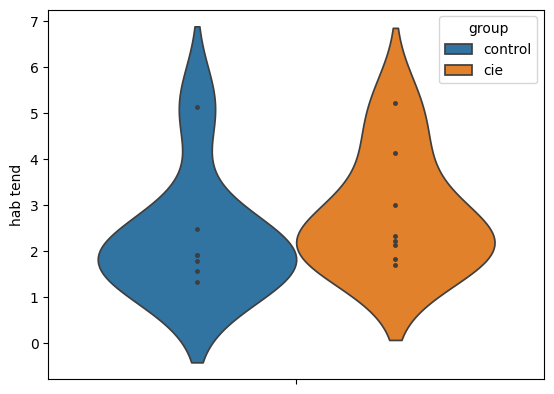

In [102]:
plt.figure()
sns.violinplot(data=group_comp_df, y="hab tend", hue="group", inner="point")
plt.show()

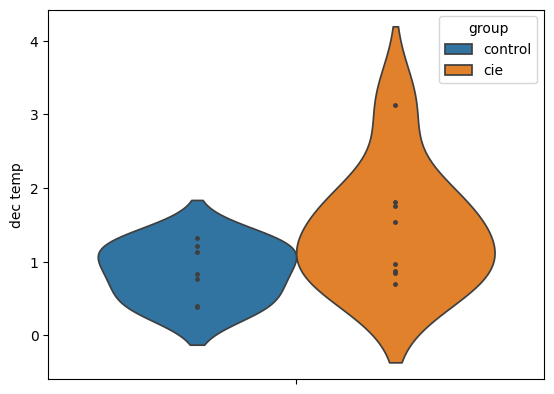

In [103]:
plt.figure()
sns.violinplot(data=group_comp_df, y="dec temp", hue="group", inner="point")
plt.show()

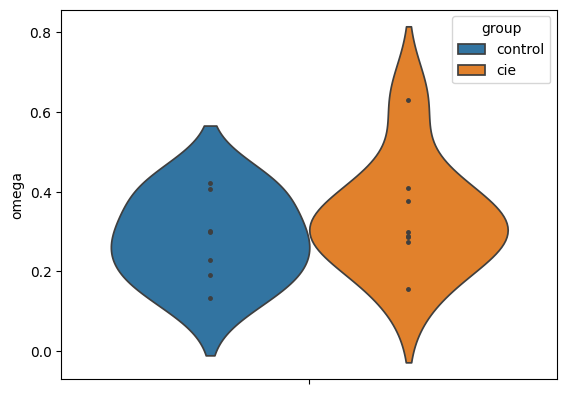

In [104]:
plt.figure()
sns.violinplot(data=group_comp_df, y="omega", hue="group", inner="point")
plt.show()

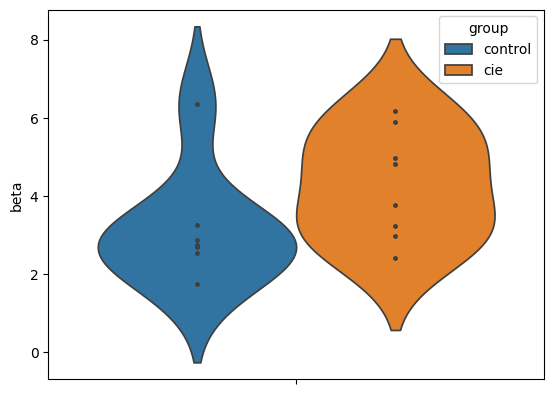

In [105]:
plt.figure()
sns.violinplot(data=group_comp_df, y="beta", hue="group", inner="point")
plt.show()

<Figure size 640x480 with 0 Axes>

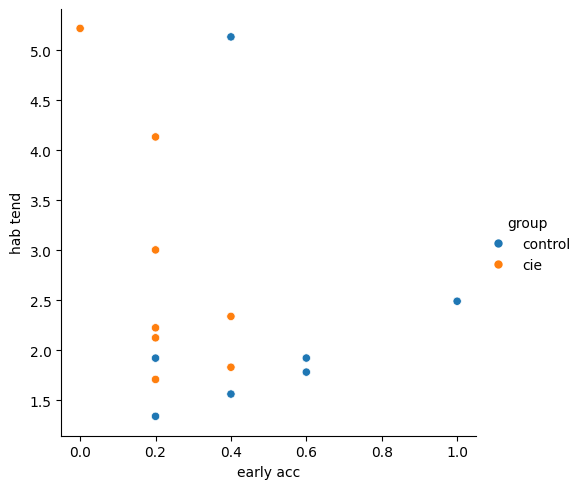

<Figure size 640x480 with 0 Axes>

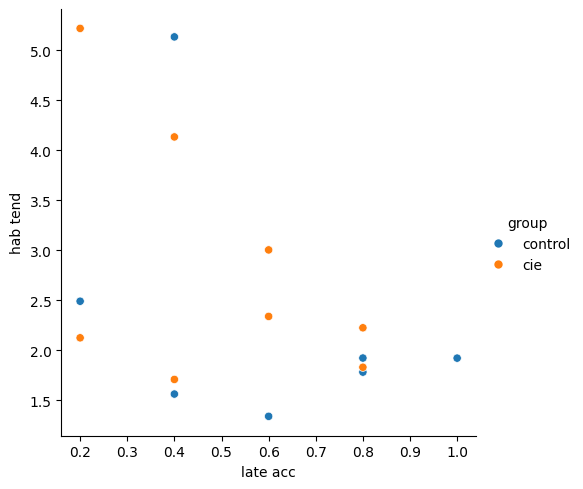

In [106]:
plt.figure()
sns.relplot(data=group_comp_df, y="hab tend", x="early acc", hue="group")
plt.show()

plt.figure()
sns.relplot(data=group_comp_df, y="hab tend", x="late acc", hue="group")
plt.show()

<Figure size 640x480 with 0 Axes>

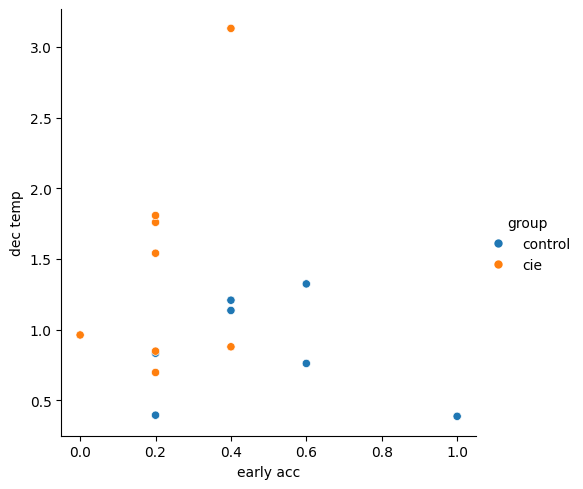

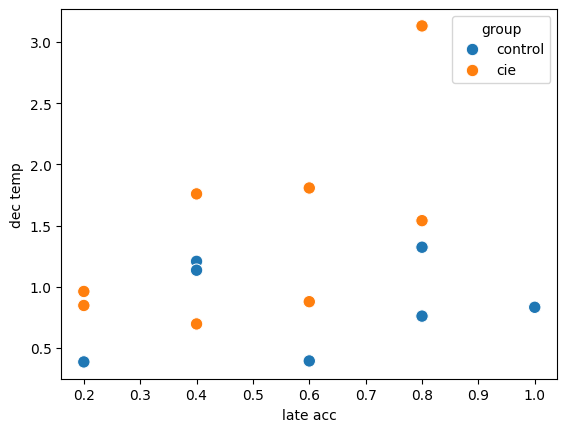

In [107]:
plt.figure()
sns.relplot(data=group_comp_df, y="dec temp", x="early acc", hue="group", sizes=(5))
plt.show()

plt.figure()
sns.scatterplot(data=group_comp_df, y="dec temp", x="late acc", hue="group", marker="o", s=80)#sizes=(200,200))
plt.show()